
# <span style="color: purple;"> Lesson 2 — Your First Machine Learning Model</span>

**Developers:** Brian &nbsp;|&nbsp; **Reviewers:** Alina, Mungo

---

### 🎯 Learning Objectives
By the end of this lesson you will be able to:
1. **Train** a simple classification model using scikit-learn
2. **Generate predictions** on new data
3. **Calculate** and interpret model accuracy

<br>

<div class="alert alert-info">

#### **How this lesson works:** Run every cell in order. *Don't worry if you don't understand everything yet* — the explanations come after you see the results.

</div>

---

## <span style="color: purple;">🧩 What is Classification?</span>

At its absolute core, the goal of Machine Learning (ML) is to **use data to generate predictions**. Instead of explicitly programming a computer with rules (like *"if the email contains the word 'lottery', then it is spam"*), we give an ML algorithm hundreds of past examples and let it figure out the rules for itself.

In general, machine learning tasks are often divided into two main types: 
- 1. **Regression** (predicting a continuous number, e.g. What will the temperature be tomorrow?)
- 2.  **Classification** (predicting a category, e.g. Is this a picture of a cat or a dog?).

In this lesson, we will be focusing on **Classification** - the task of sorting data into predefined classes. 

Here are some every-day examples of classification algorithms in action:

| Input Data | Features (measureable characteristics) | Classes (categories) to Predict |
|------------|------------------------------------|---------------------------------|
| 📧 An incoming email | Sender, Subject line, Keywords, Links | **Spam** or **Inbox** |
| 📸 A medical scan | Pixel brightness, Shapes, Textures | **Healthy** or **Tumor** |
| 🏧 A credit card transaction | Amount, Location, Time, Merchant | **Legitimate** or **Fraudulent** |
| 🖼️ A photo of an animal | Fur color, Ear shape, Tail length | **Cat**, **Dog**, or **Horse** |



---

## <span style="color: purple;">Step 1 — Load and explore the data</span>

*"If I were a botanist categorising flowers, I wouldn't just look at their colour. I'd whip out my ruler and meticulously measure their petals and sepals. Over time, I'd notice clear patterns—like one species always having long petals—and I'd use those patterns to identify any future flowers I encounter."*

That's exactly what our Machine Learning model is going to do!

#### 💪 We are trying to predict the **species** - ***class*** of an iris flower, based on its **sepal length** and **sepal width** - ***features***.

We'll use the famous **Iris dataset**, introduced by British statistician Ronald Fisher in 1936. This dataset is historically important because it is widely considered the "Hello World" of machine learning—providing a perfect, simple example of how statistical patterns can separate different biological classes.

#### **Features**:

The dataset contains 150 flowers, and **4 features** (measurements) for each.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Petal-sepal.jpg/500px-Petal-sepal.jpg" alt="Petal and Sepal Diagram" width="250" style="margin-top:10px; margin-bottom:15px; border-radius: 8px;"/>

| Feature Name | Description | Example Value |
|--------------|-------------|---------------|
| `sepal length (cm)` | Length of the sepal (outer part) | 5.1 |
| `sepal width (cm)` | Width of the sepal | 3.5 |
| `petal length (cm)` | Length of the petal (inner part) | 1.4 |
| `petal width (cm)` | Width of the petal | 0.2 |

<br>

#### **Classes**:

Each flower is labelled with one of **3 classes** (species):

|*Iris Class 1*|*Iris Class 2*|*Iris Class 3*|
|:---:|:---:|:---:|
| **Setosa** | **Versicolor** | **Virginica** |
| <img src="https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg" alt="Iris Setosa" width="200"/> | <img src="https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg" alt="Iris Versicolor" width="200"/> | <img src="https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg" alt="Iris Virginica" width="200"/> |

<br>

<div class="alert alert-info">

#### Run the cell below to load the data into a table (DataFrame) and plot two of its features.

</div>

Dataset shape: (150, 5)  →  150 rows, 5 columns


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


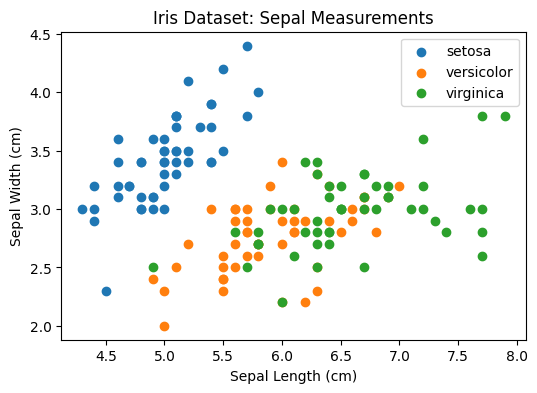

In [42]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
iris = load_iris()

# Put it in a DataFrame so it's easy to read
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]   # add the label column

print(f"Dataset shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

# Plot Sepal Length vs Sepal Width
plt.figure(figsize=(6, 4))
for i, species in enumerate(iris.target_names):
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=species)
plt.title('Iris Dataset: Sepal Measurements')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()

<div class="alert alert-info">

### 👀 What are we looking at?

- **The Table:** This shows the first 5 rows of our dataset. Each row represents a single flower, showing its four measurements (the **features**) and the species it belongs to (the **class**).

- **The Scatter Plot:** We plotted all 150 flowers based on just two of their measurements (sepal length and width). Notice how the flowers group into somewhat distinct **clusters** based on their species. For example, the *setosa* flowers (blue dots) clearly clump together, having shorter but wider sepals than the rest. 

Our machine learning model's job will be to learn the 3 ditinct clustering of datapoints corresponding to the 3 species mathematically, using all 4 measurements, so it can classify new flowers!

</div>

---

## <span style="color: purple;">Step 2 — Train the model</span>

Training a simple machine learning takes just a few lines of code! 

Don't worry if you don't understand what the code is doing - this will be covered in depth later on.

In [43]:
from sklearn.model_selection import train_test_split

X = iris.data    # features  (the 4 measurements)
y = iris.target  # labels    (species codes: 0, 1, or 2)

# 80% training data, 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)} flowers \n")
# print(f"Test samples     : {len(X_test)} flowers")

from sklearn.tree import DecisionTreeClassifier

# 1. Create the model (a Decision Tree)
model = DecisionTreeClassifier(random_state=42)

# 2. Train it — this is where the 'learning' happens
model.fit(X_train, y_train)

print("Model successfully trained!")

Training samples : 120 flowers 

Model successfully trained!


<div class="alert alert-info">

### 🎉 There you go, you have successfully trained your first machine learing model!

* The keen-eyed would notice that only 120 out of 150 flowers were used for training the model. There is a reason for this - keep going to find out.
  


</div>

---

## <span style="color: purple;">Step 3 — Make predictions and check accuracy</span>

The reason that we only used 120 (80%) of the data to train the model is that we want to reserve 20% of the data to test the model. This way, we can see how well the model managed to learn to classify iris flowers. 

Think of it like a school exam: you don't get to practice on the questions in the exam that you studied for!

Now we bring out our hidden 20% test set. We ask the model to guess the species of these new flowers. 
We then compare its guesses against the true answers to calculate an overall accuracy score.

In [44]:
from sklearn.metrics import accuracy_score

# Generate predictions on the unseen test data
y_pred = model.predict(X_test)

# Calculate what percentage it got right
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy * 100:.1f}%")

# Show a few predictions vs. true labels side-by-side
print("\nFirst 10 predictions vs. true labels:")
print("Predicted:", [iris.target_names[p] for p in y_pred[:10]])
print("Actual:   ", [iris.target_names[t] for t in y_test[:10]])

Model accuracy: 100.0%

First 10 predictions vs. true labels:
Predicted: [np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('setosa'), np.str_('versicolor'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor')]
Actual:    [np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('setosa'), np.str_('versicolor'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor')]


<div class="alert alert-info">

### ⁉️ Wait, 100% accuracy? 

* Does that mean our model is perfect? Not quite! The Iris dataset is a notoriously "easy" dataset where the rules separating the flowers are very clear-cut.

In the real world, you will almost **never** get 100% accuracy. In fact, if a real-world model gets 100% accuracy, it's usually a red flag that something went wrong (like accidentally giving the model the exam answers beforehand). But for this "Hello World" example, it just shows how powerful even simple algorithms can be!

</div>

---

## <span style="color: purple;">🧠 Key Concepts — Summary</span>

You've just completed a full Machine Learning workflow! Here are the core concepts covered:

| Term | Concept |
|------|---------|
| **Classification** | The task of sorting data into predefined categories. |
| **Features** | The characteristics or measurements used to make predictions. |
| **Classes/Labels** | The predefined categories we want our model to predict. |
| **Training** | The process where a model studies examples to discover mathematical rules and patterns. |
| **Prediction** | The model's educated guess on new, unseen data. |
| **Accuracy** | How many of the model's predictions were actually correct. |

We also learned that **we must always test our model on data it hasn't seen before**. Evaluating a model on the exact same data it learned from is cheating (like giving a student the exam paper to study from)!